# Analysis of UK Road Collision Data

This notebook demonstrates the use of Pandas, NumPy, Matplotlib, and Seaborn to analyse real-world road collision data. The objective is to explore patterns in collision severity, vehicle involvement, and casualty outcomes.

## Data Loading

The dataset consists of UK road collision data, including collisions, vehicles, and casualties. These are loaded from CSV files for analysis.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

Column names are standardised to ensure consistent referencing throughout the analysis.

In [14]:
collisions = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-collision-last-5-years.csv")
casualties = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-casualty-last-5-years.csv")
vehicles = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-vehicle-last-5-years.csv")

C:\Users\Dean\AppData\Local\Temp\ipykernel_20352\2803279281.py:3: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicles = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-vehicle-last-5-years.csv")


In [15]:
import os
os.getcwd()

'f:\\VScode\\ai-apprenticeship-session6\\Assignment'

In [16]:
os.listdir()

['assignment data', 'Session9_2_4.ipynb']

In [17]:
base_path = r"F:\VScode\ai-apprenticeship-session6\Assignment\assignment data"

collisions = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-collision-last-5-years.csv")
casualties = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-casualty-last-5-years.csv")
vehicles = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-vehicle-last-5-years.csv")

C:\Users\Dean\AppData\Local\Temp\ipykernel_20352\2647564118.py:5: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicles = pd.read_csv(f"{base_path}/dft-road-casualty-statistics-vehicle-last-5-years.csv")


## Data Exploration

Initial inspection of the dataset structure and summary statistics.

In [12]:
vehicles.dtypes

collision_index                              object
collision_year                                int64
collision_ref_no                             object
vehicle_reference                             int64
vehicle_type                                  int64
towing_and_articulation                       int64
vehicle_manoeuvre_historic                    int64
vehicle_manoeuvre                             int64
vehicle_direction_from                        int64
vehicle_direction_to                          int64
vehicle_location_restricted_lane_historic     int64
vehicle_location_restricted_lane              int64
junction_location                             int64
skidding_and_overturning                      int64
hit_object_in_carriageway                     int64
vehicle_leaving_carriageway                   int64
hit_object_off_carriageway                    int64
first_point_of_impact                         int64
vehicle_left_hand_drive                       int64
journey_purp

In [13]:
vehicles['vehicle_type'].value_counts()

vehicle_type
 9     628614
 1      81231
 19     58092
 3      44442
 5      21819
 8      14360
 11     14290
 21     13115
 4       9489
-1       6545
 2       5323
 90      5048
 98      4319
 20      4060
 97      2830
 17      2015
 22      1471
 10      1435
 23      1393
 16       379
 99       332
 18        90
Name: count, dtype: int64

In [14]:
vehicles['age_of_driver'].describe()

count    920692.000000
mean         34.676669
std          21.441331
min          -1.000000
25%          22.000000
50%          34.000000
75%          50.000000
max         101.000000
Name: age_of_driver, dtype: float64

In [15]:
vehicles['vehicle_type'] = vehicles['vehicle_type'].astype('category')
vehicles['sex_of_driver'] = vehicles['sex_of_driver'].astype('category')

In [17]:
merged = vehicles.merge(collisions, on='collision_index')

In [11]:
collisions.info()
collisions.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  object 
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  object 
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_severity                                503475 non-null  int64  
 9   numb

,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,...,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
count,503475.000000,503410.000000,5.034100e+05,503410.000000,503410.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,...,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000
mean,2022.044942,455410.085521,2.749183e+05,-1.204486,52.361673,27.511884,2.751807,1.828675,1.272202,4.137183,...,0.166741,0.115557,2.483758,1.324958,1.478429,1.723106,1.522761,0.520693,0.236950,0.748171
std,1.390050,92797.773172,1.460445e+05,1.357086,1.315858,24.296055,0.465135,0.685515,0.698575,1.935444,...,1.542713,1.427455,13.651690,0.468716,0.764157,0.792647,2.678876,0.499572,0.406133,0.415392
min,2020.000000,65947.000000,1.021100e+04,-7.497375,49.912210,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000
25%,2021.000000,392836.250000,1.750000e+05,-2.108384,51.461046,4.000000,3.000000,1.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,-1.000000,0.000000,0.000000,0.809562
50%,2022.000000,461820.500000,2.143570e+05,-1.086891,51.811436,22.000000,3.000000,2.000000,1.000000,4.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,3.000000,1.000000,0.000000,1.000000
75%,2023.000000,529754.000000,3.818590e+05,-0.130722,53.328497,45.000000,3.000000,2.000000,1.000000,6.000000,...,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,3.000000,1.000000,0.157065,1.000000
max,2024.000000,655345.000000,1.184351e+06,1.759829,60.541144,99.000000,3.000000,26.000000,70.000000,7.000000,...,9.000000,9.000000,99.000000,3.000000,3.000000,2.000000,7.000000,1.000000,1.000000,1.000000


In [18]:
collisions.head()
collisions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  object 
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  object 
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_severity                                503475 non-null  int64  
 9   numb

In [23]:
for col in collisions.columns:
    print(col)

collision_index
collision_year
collision_ref_no
location_easting_osgr
location_northing_osgr
longitude
latitude
police_force
collision_severity
number_of_vehicles
number_of_casualties
date
day_of_week
time
local_authority_district
local_authority_ons_district
local_authority_highway
local_authority_highway_current
first_road_class
first_road_number
road_type
speed_limit
junction_detail_historic
junction_detail
junction_control
second_road_class
second_road_number
pedestrian_crossing_human_control_historic
pedestrian_crossing_physical_facilities_historic
pedestrian_crossing
light_conditions
weather_conditions
road_surface_conditions
special_conditions_at_site
carriageway_hazards_historic
carriageway_hazards
urban_or_rural_area
did_police_officer_attend_scene_of_accident
trunk_road_flag
lsoa_of_accident_location
enhanced_severity_collision
collision_injury_based
collision_adjusted_severity_serious
collision_adjusted_severity_slight


In [18]:
collisions.columns = collisions.columns.str.lower().str.strip()

## Collision Severity Distribution

This section examines the frequency of collisions by severity category.

In [19]:
collisions['collision_severity'].value_counts()

collision_severity
3    386007
2    109977
1      7491
Name: count, dtype: int64

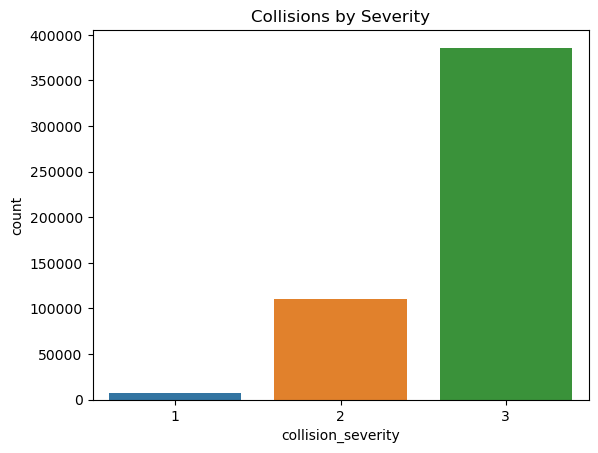

In [20]:
sns.countplot(x='collision_severity', data=collisions)
plt.title("Collisions by Severity")
plt.show()

The distribution shows that most collisions fall into lower severity categories, indicating that high severity incidents are less frequent.

## Vehicles vs Casualties

This analysis explores the relationship between the number of vehicles involved and the number of casualties.

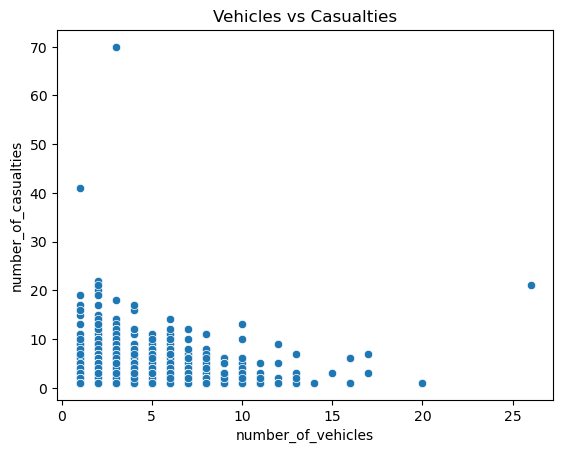

In [27]:
sns.scatterplot(
    x='number_of_vehicles',
    y='number_of_casualties',
    data=collisions
)
plt.title("Vehicles vs Casualties")
plt.show()

The majority of collisions involve a small number of vehicles and result in relatively low casualty counts. A weak positive relationship is observed, with some high-casualty outliers.

## Average Casualties by Severity

This section examines how casualty counts vary across different severity categories.

In [28]:
collisions.groupby('collision_severity')['number_of_casualties'].mean()

collision_severity
1    1.653985
2    1.355102
3    1.241174
Name: number_of_casualties, dtype: float64

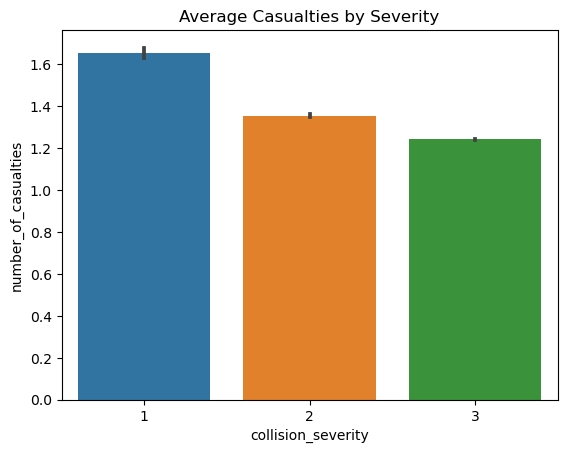

In [29]:
sns.barplot(
    x='collision_severity',
    y='number_of_casualties',
    data=collisions
)
plt.title("Average Casualties by Severity")
plt.show()

Higher severity categories are associated with increased average casualties, confirming the relationship between severity classification and impact.

## Speed Limit vs Severity

This analysis investigates whether speed limits are associated with collision severity.

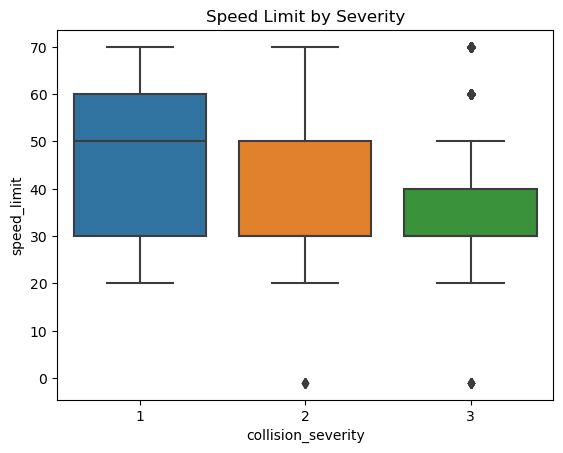

In [30]:
sns.boxplot(
    x='collision_severity',
    y='speed_limit',
    data=collisions
)
plt.title("Speed Limit by Severity")
plt.show()

Higher speed limits appear to be associated with more severe collisions, although variation suggests other contributing factors.

<Axes: xlabel='number_of_vehicles', ylabel='number_of_casualties'>

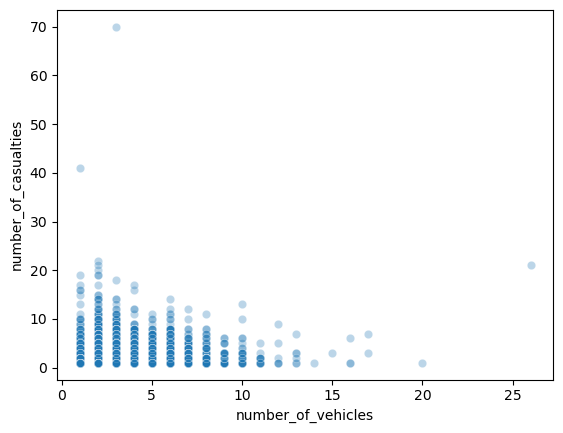

In [32]:
sns.scatterplot(
    x='number_of_vehicles',
    y='number_of_casualties',
    data=collisions,
    alpha=0.3
)

<Axes: xlabel='number_of_vehicles', ylabel='number_of_casualties'>

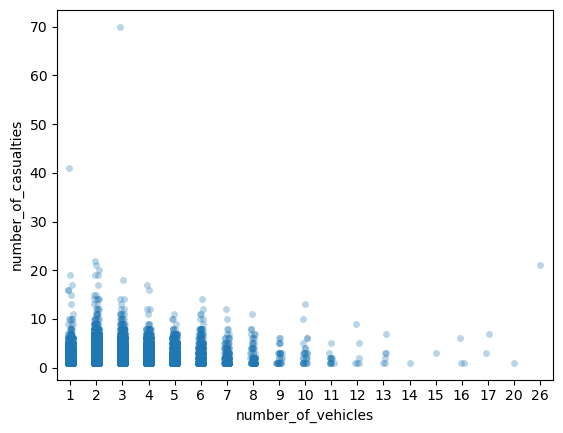

In [33]:
sns.stripplot(
    x='number_of_vehicles',
    y='number_of_casualties',
    data=collisions,
    alpha=0.3
)

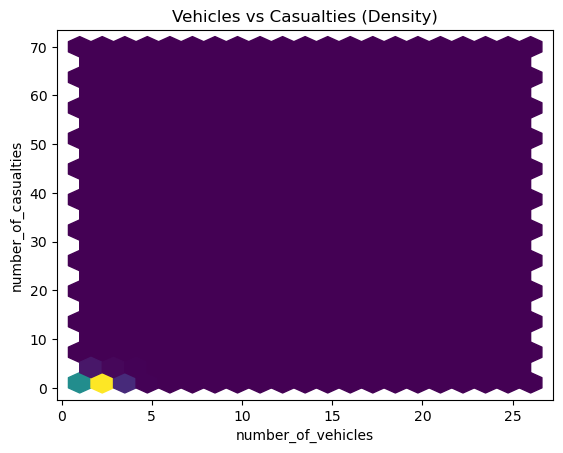

In [34]:
plt.hexbin(
    collisions['number_of_vehicles'],
    collisions['number_of_casualties'],
    gridsize=20
)
plt.xlabel("number_of_vehicles")
plt.ylabel("number_of_casualties")
plt.title("Vehicles vs Casualties (Density)")
plt.show()

<Axes: xlabel='number_of_vehicles', ylabel='number_of_casualties'>

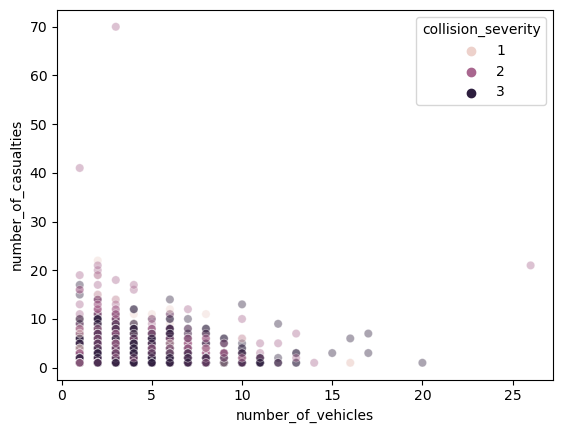

In [35]:
sns.scatterplot(
    x='number_of_vehicles',
    y='number_of_casualties',
    hue='collision_severity',
    data=collisions,
    alpha=0.4
)

The majority of collisions involve a small number of vehicles and result in relatively low casualty counts. While there is a weak positive relationship between vehicle count and casualties, the presence of high-casualty outliers indicates that additional factors beyond vehicle count influence collision severity.